In [1]:
import torch
import torch.nn as nn
import numpy as np
import gymnasium as gym
import gymnasium.spaces as spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

# ATT&CK技术映射（示例）
TECHNIQUE_MAP = {
    0: "T1595_扫描侦查",
    1: "T1190_SQL注入", 
    2: "T1193_恶意软件投递",
    3: "T1598_钓鱼攻击",
    4: "T1105_C2通信",
    5: "T1499_流量泛洪"
}

# ATT&CK因果奖励矩阵（根据官方知识库构建）
ATTACK_MATRIX = np.array([
    # T1595 T1190 T1193 T1598 T1105 T1499
    [0,    0.9,  0.2,   0.3,  0.1,   0.1],  # T1595
    [0,    0,    0.8,   0.1,  0.6,   0.1],  # T1190
    [0,    0,    0,     0.2,  0.9,   0.3],  # T1193
    [0,    0,    0.7,   0,    0.4,   0.1],  # T1598
    [0,    0,    0,     0,    0,     0.5],  # T1105
    [0,    0,    0,     0,    0,     0]     # T1499
])

class AttackChainEnv(gym.Env):
    def __init__(self, sequences, max_steps=20):
        self.sequences = sequences
        self.max_steps = max_steps
        self.n_tech = len(TECHNIQUE_MAP)
        
        # 修改动作空间：只允许选择不同的源和目标节点
        self.action_space = spaces.Discrete((self.n_tech * (self.n_tech - 1)))  # 减少动作空间
        
        # 观测空间：LSTM编码序列 + 当前因果图
        self.observation_space = spaces.Dict({
            "sequence": spaces.Box(low=-np.inf, high=np.inf, shape=(128,), dtype=np.float32),
            "graph": spaces.Box(low=0, high=1, shape=(self.n_tech, self.n_tech), dtype=np.float32)
        })
        
        # LSTM序列编码器
        self.lstm = nn.LSTM(input_size=self.n_tech, hidden_size=128, batch_first=True, num_layers=1)
        
        # 当前状态
        self.current_seq = None
        self.causal_graph = None  # 在reset中初始化
        self.available_edges = None  # 在reset中初始化
        self.step_count = 0

    def _encode_sequence(self, seq):
        """编码攻击序列为LSTM隐藏状态"""
        with torch.no_grad():
            # 将序列转换为one-hot编码
            seq_oh = nn.functional.one_hot(torch.LongTensor(seq), self.n_tech).float()
            # 添加批处理维度
            seq_oh = seq_oh.unsqueeze(0)
            # 通过LSTM
            _, (hidden, _) = self.lstm(seq_oh)
            # 处理输出维度
            hidden = hidden[-1]  # 取最后一层
            # 转换为numpy并确保维度正确
            return hidden.numpy().reshape(-1).astype(np.float32)

    def _get_obs(self):
        return {
            "sequence": self._encode_sequence(self.current_seq),
            "graph": self.causal_graph.copy()
        }
    
    def _init_available_edges(self):
        """初始化可用边的矩阵"""
        self.available_edges = np.zeros((self.n_tech, self.n_tech), dtype=bool)
        for row in range(len(ATTACK_MATRIX)):
            for col in range(len(ATTACK_MATRIX[0])):
                if ATTACK_MATRIX[row, col] > 0:  # 只有在奖励矩阵中有正向值的边才可用
                    self.available_edges[row, col] = True
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_seq = self.sequences[np.random.choice(len(self.sequences))]
        self.causal_graph = np.zeros((self.n_tech, self.n_tech))
        self._init_available_edges()
        self.step_count = 0
        obs = self._get_obs()
         # print(f"重置环境,当前序列: {[TECHNIQUE_MAP[i] for i in self.current_seq]}")
        return obs, {}

    def _calculate_reward(self, src, dst):
        """基于ATT&CK矩阵的因果奖励"""
        # 添加调试信息
        # print(f"计算奖励 - 源节点:{src}({TECHNIQUE_MAP[src]}), 目标节点:{dst}({TECHNIQUE_MAP[dst]})")
        # print(f"当前序列: {[TECHNIQUE_MAP[i] for i in self.current_seq]}")
        
        # 如果是重复的边或不可用的边，给予负奖励
        if self.causal_graph[src, dst] == 1:
            # print("重复边,奖励:-0.5")
            return -0.5
        if not self.available_edges[src, dst]:
            # print(self.available_edges)
            # print(self.available_edges[src,dst])
            # print("不可用的边,奖励:-0.5")
            # print(f"原因: 1) 源节点或目标节点不在序列中 或 2) 不符合时间顺序 或 3) 在ATT&CK矩阵中无关联")
            return -0.5
        if src == dst:
            # 避免自环
            return -0.5    
        # 基础因果奖励
        base_reward = ATTACK_MATRIX[src, dst]
        # print(f"基础因果奖励: {base_reward}")
        
        # 数据驱动调整（计算ATE）
        ate = self._compute_ate(src, dst)
        print(f"ATE: {ate}")
        adjusted_reward = 0.7*base_reward + 0.3*ate
        # print(f"调整后奖励: {adjusted_reward}")
        
        # 降低稀疏性惩罚
        sparsity_penalty = 0.1 * (len(self.current_seq) * len(self.current_seq))/ (np.sum(self.causal_graph) + 1)
        # print(f"稀疏性惩罚: {sparsity_penalty}")
        
        # 有效性检查
        validity = 0.5 if self._is_valid_edge(src, dst) else -0.5
        # print(f"有效性检查: {validity}")
        
        # 归一化奖励
        reward = adjusted_reward - sparsity_penalty + validity
        # print(f"最终奖励: {reward}")
        return float(np.clip(reward, -1.0, 1.0))

    def _compute_ate(self, src, dst):
        """计算实际数据中的平均处理效应"""
        valid_count = 0
        total = 0
        for seq in self.sequences:
            if src in seq and dst in seq:
                total += 1
                if seq.index(src) < seq.index(dst):
                    valid_count += 1
        return valid_count / (total + 1e-8)

    def _is_valid_edge(self, src, dst):
        """验证边有效性（时间顺序）"""
        if src not in self.current_seq or dst not in self.current_seq:
            return False  # 如果节点不在序列中，直接返回False
        return self.current_seq.index(src) < self.current_seq.index(dst)

    def step(self, action):
        # 将动作转换为有效的源和目标节点（避免自环）
        src = action // (self.n_tech - 1)
        dst_temp = action % (self.n_tech - 1)
        dst = dst_temp + 1 if dst_temp >= src else dst_temp
        
        # print(f"\n执行动作: {action}")
        # print(f"转换后的源节点和目标节点: src={src}, dst={dst}")
        
        # 检查src和dst是否都在current_seq中
        if src not in self.current_seq or dst not in self.current_seq:
            # print("源节点或目标节点不在当前序列中")
            return self._get_obs(), -0.5, False, False, {
                'valid_edge': 0.0,
                'base_reward': 0.0,
                'ate': 0.0,
                'src': src,
                'dst': dst,
                'available_edges': self.available_edges.sum()
            }
        
        # 只有当边是可用的时候才更新图
        if self.available_edges[src, dst]:
            self.causal_graph[src, dst] = 1
        
        reward = self._calculate_reward(src, dst)
        self.step_count += 1
        
        terminated = self.step_count >= self.max_steps or np.all(self.causal_graph[self.available_edges])
        truncated = False
        
        info = {
            'valid_edge': float(self._is_valid_edge(src, dst)),
            'base_reward': float(ATTACK_MATRIX[src, dst]),
            'ate': float(self._compute_ate(src, dst)),
            'src': src,
            'dst': dst,
            'available_edges': self.available_edges.sum()
        }
        
        # print(f"步数: {self.step_count}/{self.max_steps}")
        # print(f"信息: {info}")
        
        return self._get_obs(), reward, terminated, truncated, info

class CustomFeatureExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space):
        super().__init__(observation_space, features_dim=256)
        
        # 序列处理分支
        self.seq_net = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU()
        )
        
        # 图处理分支
        self.graph_net = nn.Sequential(
            nn.Linear(6 * 6, 64),
            nn.ReLU()
        )
        
        # 联合特征
        self.joint_net = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU()
        )

    def forward(self, observations):
        # 确保序列特征维度正确
        seq = observations["sequence"]
        if len(seq.shape) == 1:
            seq = seq.unsqueeze(0)
        
        # 序列特征
        seq_feat = self.seq_net(seq)
        
        # 图特征（展平）
        graph = observations["graph"]
        if len(graph.shape) == 2:
            graph = graph.unsqueeze(0)
        graph_feat = self.graph_net(graph.reshape(graph.shape[0], -1))
        
        # 特征融合
        joint = torch.cat([seq_feat, graph_feat], dim=1)
        return self.joint_net(joint)


In [2]:
# 训练流程
# 根据ATT&CK因果奖励矩阵生成合理的攻击序列
def generate_sequences():
    base_seqs = []
    
    # 根据奖励矩阵生成高奖励路径
    # T1595(0) -> T1190(1) -> T1193(2) -> T1105(4)  # 扫描->注入->投递->C2
    base_seqs.append([0,1,2,4])
    
    # T1595(0) -> T1598(3) -> T1193(2) -> T1105(4)  # 扫描->钓鱼->投递->C2
    base_seqs.append([0,3,2,4])
    
    # T1190(1) -> T1193(2) -> T1105(4) -> T1499(5)  # 注入->投递->C2->泛洪
    base_seqs.append([1,2,4,5])
    
    # 其他常见组合
    base_seqs.extend([
        [0,1,4],  # 扫描->注入->C2
        [1,2,4],  # 注入->投递->C2
        [0,3,2,4],  # 扫描->钓鱼->投递->C2
        [2,4,5],  # 投递->C2->泛洪
        [3,2,4]   # 钓鱼->投递->C2
    ])
    
    return base_seqs * 30  # 生成足够的训练样本

# 创建环境
env = make_vec_env(
    lambda: AttackChainEnv(generate_sequences(), max_steps=10),  # 减少最大步数
    n_envs=4,  # 增加环境数量
    seed=42
)

# 配置PPO
policy_kwargs = dict(
    features_extractor_class=CustomFeatureExtractor,
    net_arch=dict(
        pi=[128,64],  # 简化策略网络
        vf=[128,64]   # 简化价值网络
    )
)

# 创建回调函数来记录训练数据
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import numpy as np

class TrainingCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.rewards = []
        self.losses = []
        
    def _on_step(self):
        # 记录每步的奖励
        self.rewards.append(np.mean([ep_info["r"] for ep_info in self.model.ep_info_buffer]))
        # 记录损失值
        if len(self.model.logger.name_to_value) > 0:
            self.losses.append(self.model.logger.name_to_value.get('train/loss', 0))
        return True
        
    def plot_metrics(self):
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(self.rewards)
        plt.title('average reward')
        plt.xlabel('training steps')
        plt.ylabel('reward value')
        
        plt.subplot(1, 2, 2)
        plt.plot(self.losses)
        plt.title('training loss')
        plt.xlabel('training steps')
        plt.ylabel('loss value')
        
        plt.tight_layout()
        plt.show()

callback = TrainingCallback()

model = PPO(
    "MultiInputPolicy",
    env,
    policy_kwargs=policy_kwargs,
    verbose=1,
    n_steps=512,      # 减小步数
    batch_size=64,    # 减小批量
    n_epochs=20,      # 增加每批数据的训练轮数
    learning_rate=1e-4,  # 降低学习率
    gamma=0.95,       # 调整折扣因子
    clip_range=0.1,   # 减小裁剪范围
    ent_coef=0.1,    # 增加熵系数，鼓励探索
    max_grad_norm=0.5,  # 添加梯度裁剪
    tensorboard_log="./ppo_logs"
)

# 训练
try:
    model.learn(total_timesteps=1e5, callback=callback)
except Exception as e:
    print(f"error in training: {e}")

Using cpu device
Logging to ./ppo_logs\PPO_1


f:\python3\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
f:\python3\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 36.6     |
|    ep_rew_mean     | -18.3    |
| time/              |          |
|    fps             | 1176     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 36.1         |
|    ep_rew_mean          | -18          |
| time/                   |              |
|    fps                  | 575          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0021205954 |
|    clip_fraction        | 0.0801       |
|    clip_range           | 0.1          |
|    entropy_loss         | -3.4         |
|    explained_variance   | 0.0464       |
|    learning_r

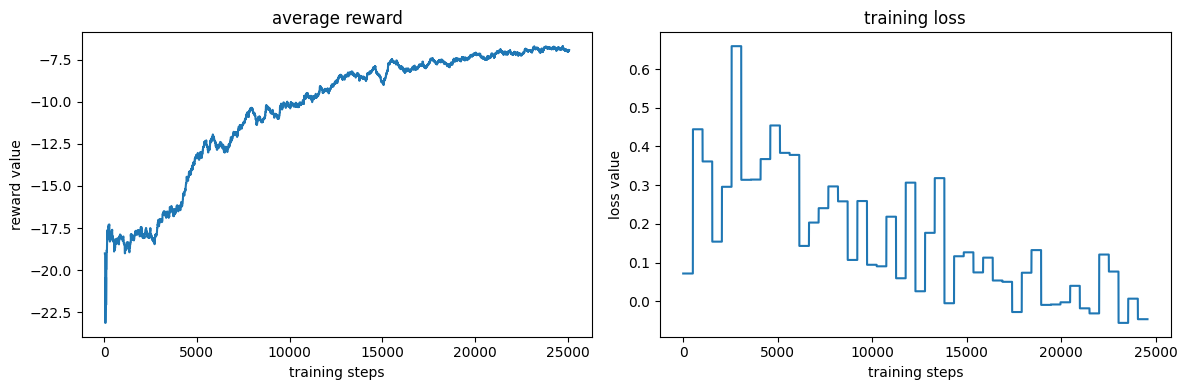

In [3]:
# 训练完成后绘制指标图
callback.plot_metrics()

In [4]:
# 推理示例代码
def predict_and_visualize(model, env):
    obs = env.reset()[0]
    total_reward = 0
    edges_added = []
    
    print("推理过程：")
    for step in range(20):  # 限制最大步数,避免无限循环
        action, _ = model.predict(obs, deterministic=True)
        
        # 转换动作到实际的源和目标节点
        src = action // (env.n_tech - 1)
        dst_temp = action % (env.n_tech - 1)
        dst = dst_temp + 1 if dst_temp >= src else dst_temp
        
        print(f"步骤 {step}:")
        print(f"- 选择的动作: {action}")
        print(f"- 源技术: {src} ({TECHNIQUE_MAP[src]})")
        print(f"- 目标技术: {dst} ({TECHNIQUE_MAP[dst]})")
        
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        
        print(f"- 奖励: {reward}")
        print(f"- 是否终止: {terminated}")
        print(f"- 是否截断: {truncated}")
        
        # 检查奖励值
        if reward >= -1:  # 修改判断条件,允许0奖励也添加边
            edges_added.append((src, dst))
            print(f"- 添加边! 关联强度: {ATTACK_MATRIX[src,dst]:.2f}")
        print()
        
        if terminated or truncated:
            break

    print(f"\n总奖励: {total_reward:.2f}")
    print("\n生成的因果关联图：")
    
    # 打印更详细的调试信息
    print("\n所有动作的奖励值:")
    for src, dst in edges_added:
        print(f"{TECHNIQUE_MAP[src]} → {TECHNIQUE_MAP[dst]}")
        print(f"- 关联强度: {ATTACK_MATRIX[src,dst]:.2f}")
        print(f"- 奖励值判断: {reward >= 0}")

    if len(edges_added) == 0:
        print("\n警告:没有生成任何边!")
        print("可能的原因:")
        print("1. 所有动作的奖励值均为负")
        print("2. 模型没有学习到有效的策略")
        print("3. 环境配置可能需要调整")

    return edges_added

# 根据常见攻击链生成测试序列
test_seqs = ([
    [0,1,2,4],  # 扫描->注入->投递->C2
    [0,3,2,4],  # 扫描->钓鱼->投递->C2 
    [1,2,4,5],  # 注入->投递->C2->泛洪
    [0,1,4],    # 扫描->注入->C2
    [1,2,4],    # 注入->投递->C2
    [2,4,5],    # 投递->C2->泛洪
    [3,2,4]     # 钓鱼->投递->C2
])
# 使用新的推理函数和测试序列
test_env = AttackChainEnv([test_seqs[3]])
edges_added = predict_and_visualize(model, test_env)

推理过程：
步骤 0:
- 选择的动作: 8
- 源技术: 1 (T1190_SQL注入)
- 目标技术: 4 (T1105_C2通信)
- 奖励: -0.5
- 是否终止: False
- 是否截断: False
- 添加边! 关联强度: 0.60

步骤 1:
- 选择的动作: 0
- 源技术: 0 (T1595_扫描侦查)
- 目标技术: 1 (T1190_SQL注入)
- 奖励: -0.5
- 是否终止: False
- 是否截断: False
- 添加边! 关联强度: 0.90

步骤 2:
- 选择的动作: 0
- 源技术: 0 (T1595_扫描侦查)
- 目标技术: 1 (T1190_SQL注入)
- 奖励: -0.5
- 是否终止: False
- 是否截断: False
- 添加边! 关联强度: 0.90

步骤 3:
- 选择的动作: 0
- 源技术: 0 (T1595_扫描侦查)
- 目标技术: 1 (T1190_SQL注入)
- 奖励: -0.5
- 是否终止: False
- 是否截断: False
- 添加边! 关联强度: 0.90

步骤 4:
- 选择的动作: 0
- 源技术: 0 (T1595_扫描侦查)
- 目标技术: 1 (T1190_SQL注入)
- 奖励: -0.5
- 是否终止: False
- 是否截断: False
- 添加边! 关联强度: 0.90

步骤 5:
- 选择的动作: 0
- 源技术: 0 (T1595_扫描侦查)
- 目标技术: 1 (T1190_SQL注入)
- 奖励: -0.5
- 是否终止: False
- 是否截断: False
- 添加边! 关联强度: 0.90

步骤 6:
- 选择的动作: 0
- 源技术: 0 (T1595_扫描侦查)
- 目标技术: 1 (T1190_SQL注入)
- 奖励: -0.5
- 是否终止: False
- 是否截断: False
- 添加边! 关联强度: 0.90

步骤 7:
- 选择的动作: 0
- 源技术: 0 (T1595_扫描侦查)
- 目标技术: 1 (T1190_SQL注入)
- 奖励: -0.5
- 是否终止: False
- 是否截断: False
- 添加边! 关联强度: 0.90

步骤 8:
- 选择的动作: 0
- 源技术: 0 

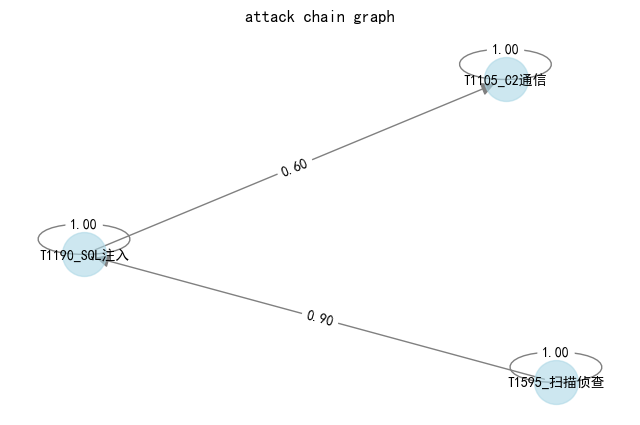

In [5]:
def plot_interactive_graph(edges_added):
    import networkx as nx
    import matplotlib.pyplot as plt
    #中文支持
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    # 创建有向图
    G = nx.DiGraph()
    
    # 添加所有节点
    all_nodes = set()
    for src, dst in edges_added:
        all_nodes.add(TECHNIQUE_MAP[src])
        all_nodes.add(TECHNIQUE_MAP[dst])
    for node in all_nodes:
        G.add_node(node)
    
    # 根据edges_added添加边
    for src, dst in edges_added:
        G.add_edge(TECHNIQUE_MAP[src], TECHNIQUE_MAP[dst], 
                  weight=ATTACK_MATRIX[src,dst])
        
    # 为每个节点添加指向自身的边
    for node in G.nodes():
        G.add_edge(node, node, weight=1.0)
    
    # 设置绘图大小
    plt.figure(figsize=(8, 5))
    
    pos = nx.spring_layout(G)
    
    # 绘制节点
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                          node_size=1000, alpha=0.6)
    
    # 绘制边
    nx.draw_networkx_edges(G, pos, edge_color='gray',
                          arrows=True, arrowsize=20)
    
    # 添加标签
    nx.draw_networkx_labels(G, pos, font_size=10)
    
    # 绘制边的权重标签
    edge_labels = nx.get_edge_attributes(G, 'weight')
    edge_labels = {k: f'{v:.2f}' for k,v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels)
    
    plt.title("attack chain graph")
    plt.axis('off')
    plt.show()

plot_interactive_graph(edges_added)